# Week 5: Simplified R-Learner-style Residual Model
Trong notebook này, chúng ta xây dựng simplified R-Learner-style residual model để dự đoán CATE. Implementation gồm outcome residualization và effect model, nhưng chưa dùng cross-fitting nên không được gọi là full DML. 
Khác với T-Learner hay S-Learner, R-Learner tập trung vào việc "residualize" (khử nhiễu nền) Outcome và Treatment trước khi học tín hiệu nhân quả.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Tải dữ liệu
data_path = '../../data/processed/segmented_simulation_data.csv'
df = pd.read_csv(data_path)
df['is_credit_card'] = (df['payment_type'] == 1).astype(int)
print(f"Tổng số User: {len(df):,}")

# Các đặc trưng (Features)
features = ['age', 'is_urban', 'preferred_hour', 'is_rush_hour', 'is_airport_trip', 'is_rain_rider', 'is_weekend_rider', 'is_credit_card', 'passenger_count', 'monthly_rides_history', 'recency_days']

X = df[features]
y = df['Y_rand']
T = df['treatment_rand']

# Chia tập Train/Validation/Test (60/20/20)
X_tv, X_test, y_tv, y_test, T_tv, T_test = train_test_split(X, y, T, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val, T_train, T_val = train_test_split(X_tv, y_tv, T_tv, test_size=0.25, random_state=42)

df_test = df.loc[X_test.index].copy()
df_test['avg_fare'] = df_test['avg_fare_per_trip']
print(f"Test set size: {len(df_test):,}")

Tổng số User: 20,000
Test set size: 4,000


## Bước 1: Huấn luyện mô hình cơ sở (Base Outcome) và Khử nhiễu
Dự đoán số chuyến đi tự nhiên mà không phụ thuộc vào Voucher.

In [2]:
params_y = dict(random_state=42, n_estimators=100, learning_rate=0.05, max_depth=4)
m_y = xgb.XGBRegressor(**params_y)
m_y.fit(X_train, y_train)

# Tính Residuals
p = 0.5  # Do RCT 50/50
Y_tilde = y_train - m_y.predict(X_train)
T_tilde = T_train - p

## Bước 2: Học tín hiệu nhân quả (CATE) trên Residuals
Trọng số học được tối ưu hóa dựa trên phương sai của Treatment.

In [3]:
uplift_target = Y_tilde / T_tilde
weights = T_tilde ** 2

params_cate = dict(random_state=42, n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=10)
r_model = xgb.XGBRegressor(**params_cate)
r_model.fit(X_train, uplift_target, sample_weight=weights)

# Dự đoán CATE trên Test set
cate_pred = r_model.predict(X_test)
df_test['cate_pred'] = cate_pred
df_test['pred_rides_treated'] = m_y.predict(X_test) + 0.5 * cate_pred

print(f"Mean predicted CATE: {cate_pred.mean():.4f}")

Mean predicted CATE: 0.9551


## Bước 4: Đánh giá bằng Qini Curve & AUUC
Đường cong Qini đo lường khả năng Xếp hạng (Ranking) khách hàng của R-Learner. Đường cong càng vồng lên cao so với đường Random (phát ngẫu nhiên), mô hình càng có khả năng nhắm mục tiêu chính xác những người nhạy cảm với khuyến mãi.

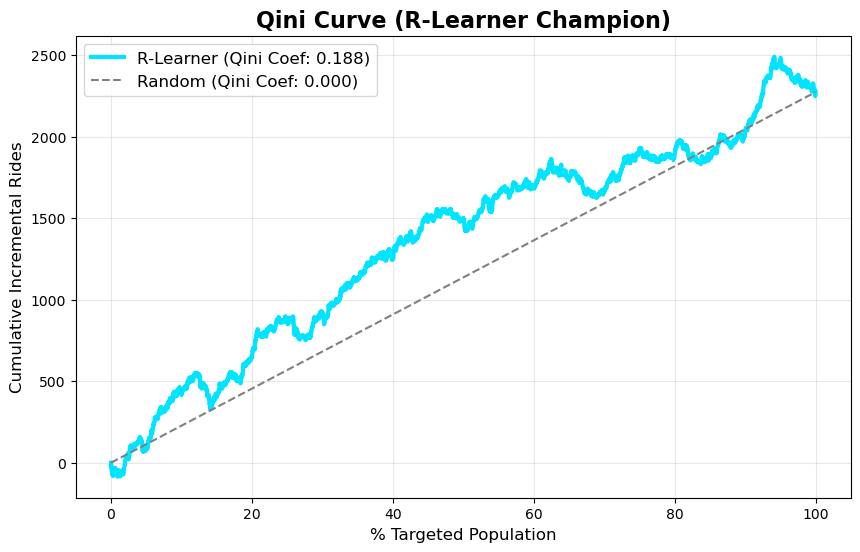

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
df_res = pd.DataFrame({
    'y_true': df_test['Y_rand'],
    'T': df_test['treatment_rand'],
    'CATE_pred': df_test['cate_pred']
})

def plot_qini_curve(df_res, title='Qini Curve (R-Learner Champion)', model_label='R-Learner'):
    df_sorted = df_res.sort_values(by='CATE_pred', ascending=False).reset_index(drop=True)
    df_sorted['T_count'] = df_sorted['T'].cumsum()
    df_sorted['C_count'] = (1 - df_sorted['T']).cumsum()
    df_sorted['Y_T_sum'] = (df_sorted['y_true'] * df_sorted['T']).cumsum()
    df_sorted['Y_C_sum'] = (df_sorted['y_true'] * (1 - df_sorted['T'])).cumsum()
    df_sorted['C_count'] = df_sorted['C_count'].replace(0, 1)
    df_sorted['Qini'] = df_sorted['Y_T_sum'] - df_sorted['Y_C_sum'] * (df_sorted['T_count'] / df_sorted['C_count'])
    total_uplift = df_sorted['Qini'].iloc[-1]
    df_sorted['Random_Qini'] = np.linspace(0, total_uplift, len(df_sorted))
    auuc_model = np.trapz(df_sorted['Qini'], dx=1)
    auuc_random = np.trapz(df_sorted['Random_Qini'], dx=1)
    qini_coef = (auuc_model - auuc_random) / auuc_random if auuc_random != 0 else 0
    plt.figure(figsize=(10, 6))
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['Qini'], label=f'{model_label} (Qini Coef: {qini_coef:.3f})', color='#00E5FF', linewidth=3)
    plt.plot(df_sorted.index / len(df_sorted) * 100, df_sorted['Random_Qini'], label=f'Random (Qini Coef: 0.000)', color='gray', linestyle='--')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('% Targeted Population', fontsize=12)
    plt.ylabel('Cumulative Incremental Rides', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()

plot_qini_curve(df_res)


## Bước 5: Đánh giá Kinh tế & Policy Simulator
Chuyển đổi CATE (số chuyến đi tăng thêm) thành Giá trị Kinh tế (Expected Incremental Profit).
Công thức: $EV = CATE \times Margin - Predicted\_Rides \times Voucher\_Cost$

In [5]:
VOUCHER_RATE = 0.15
MARGIN_RATE = 0.70
CAMPAIGN_BUDGET = 50000

df_test['voucher_cost'] = df_test['avg_fare'] * VOUCHER_RATE
df_test['margin_per_ride'] = df_test['avg_fare'] * MARGIN_RATE
df_test['expected_value'] = (df_test['cate_pred'] * df_test['margin_per_ride']) - (df_test['pred_rides_treated'] * df_test['voucher_cost'])

if 'cate_true' in df_test.columns:
    df_test['oracle_ev'] = (df_test['cate_true'] * df_test['margin_per_ride']) - (df_test['pred_rides_treated'] * df_test['voucher_cost'])

def evaluate_policy(mask, name):
    targeted = df_test[mask]
    n_t = mask.sum()
    if n_t == 0: return {"Policy": name, "Users": 0, "Predicted Profit": 0, "Oracle Profit": 0}
    
    pred_ev = targeted['expected_value'].sum()
    gt_ev = targeted['oracle_ev'].sum() if 'oracle_ev' in df_test.columns else pred_ev
    return {"Policy": name, "Users": int(n_t), "Predicted Profit": round(pred_ev, 0), "Oracle Profit": round(gt_ev, 0)}

policies = []
# 1. Mass Voucher
policies.append(evaluate_policy(df_test['cate_pred'].notnull(), "1. Mass Voucher"))
# 2. Segment (Suburban)
policies.append(evaluate_policy(df_test['persona'].str.contains('Suburban', na=False), "2. Segment Targeting (Suburban)"))
# 3. Profit Targeting (EV > 0)
policies.append(evaluate_policy(df_test['expected_value'] > 0, "3. AI Profit Targeting"))
# 4. Oracle
if 'cate_true' in df_test.columns:
    policies.append(evaluate_policy(df_test['oracle_ev'] > 0, "4. Oracle Targeting"))

pd.DataFrame(policies)

,Policy,Users,Predicted Profit,Oracle Profit
0,1. Mass Voucher,4000,-65358.0,-76313.0
1,2. Segment Targeting (Suburban),1660,-4286.0,-996.0
2,3. AI Profit Targeting,888,7939.0,7060.0
3,4. Oracle Targeting,1002,4971.0,10818.0


## Buoc 6: DR-Learner (Challenger Model)
DR-Learner tao mot nhan CATE tam thoi bang cach lay chenh lech giua hai outcome models `mu_1 - mu_0`, sau do sua chenh lech nay bang sai so thuc te quan sat duoc.

Trong notebook nay, DR-Learner duoc them nhu mot challenger de so voi R-Learner champion tren cung test set, cung Qini Curve va cung policy simulator.

In [ ]:
# DR-Learner: outcome models mu_0(x) and mu_1(x)
params_dr_outcome = dict(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8
)

mu_0 = xgb.XGBRegressor(**params_dr_outcome)
mu_1 = xgb.XGBRegressor(**params_dr_outcome)

mu_0.fit(X_train[T_train == 0], y_train[T_train == 0])
mu_1.fit(X_train[T_train == 1], y_train[T_train == 1])

# Du lieu la RCT 50/50 nen propensity e(x) = 0.5.
# Neu campaign khong con random 50/50, thay e bang propensity model hoac T_train.mean().
e = 0.5

# Tao DR pseudo-outcome tren validation set de giam in-sample bias.
mu0_val = mu_0.predict(X_val)
mu1_val = mu_1.predict(X_val)

dr_target = (
    mu1_val - mu0_val
    + (T_val / e) * (y_val - mu1_val)
    - ((1 - T_val) / (1 - e)) * (y_val - mu0_val)
)

# Final CATE model: hoc pattern X -> DR pseudo-outcome.
params_dr_cate = dict(
    random_state=42,
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=10,
    subsample=0.9,
    colsample_bytree=0.9
)

dr_model = xgb.XGBRegressor(**params_dr_cate)
dr_model.fit(X_val, dr_target)

# Predict CATE tren cung test set voi R-Learner
df_dr_test = df.loc[X_test.index].copy()
df_dr_test['avg_fare'] = df_dr_test['avg_fare_per_trip']
df_dr_test['cate_pred'] = dr_model.predict(X_test)
df_dr_test['pred_rides_treated'] = mu_1.predict(X_test)

print(f"Mean predicted CATE (DR-Learner): {df_dr_test['cate_pred'].mean():.4f}")

## Buoc 7: Danh gia DR-Learner bang Qini Curve
Neu duong Qini cua DR-Learner nam cao hon random baseline va tot hon R-Learner, model dang rank khach hang nhay voi voucher tot hon.

In [ ]:
df_res_dr = pd.DataFrame({
    'y_true': df_dr_test['Y_rand'],
    'T': df_dr_test['treatment_rand'],
    'CATE_pred': df_dr_test['cate_pred']
})

plot_qini_curve(df_res_dr, title='Qini Curve (DR-Learner Challenger)', model_label='DR-Learner')

## Buoc 8: Policy Simulator cho DR-Learner
Phan nay dung cung economics assumption voi R-Learner de xem DR-Learner co tao policy loi nhuan tot hon khong.

In [ ]:
df_dr_test['voucher_cost'] = df_dr_test['avg_fare'] * VOUCHER_RATE
df_dr_test['margin_per_ride'] = df_dr_test['avg_fare'] * MARGIN_RATE
df_dr_test['expected_value'] = (
    df_dr_test['cate_pred'] * df_dr_test['margin_per_ride']
    - df_dr_test['pred_rides_treated'] * df_dr_test['voucher_cost']
)

if 'cate_true' in df_dr_test.columns:
    df_dr_test['oracle_ev'] = (
        df_dr_test['cate_true'] * df_dr_test['margin_per_ride']
        - df_dr_test['pred_rides_treated'] * df_dr_test['voucher_cost']
    )

def evaluate_policy_dr(mask, name):
    targeted = df_dr_test[mask]
    n_t = mask.sum()
    if n_t == 0:
        return {"Policy": name, "Users": 0, "Predicted Profit": 0, "Oracle Profit": 0}

    pred_ev = targeted['expected_value'].sum()
    gt_ev = targeted['oracle_ev'].sum() if 'oracle_ev' in df_dr_test.columns else pred_ev
    return {
        "Policy": name,
        "Users": int(n_t),
        "Predicted Profit": round(pred_ev, 0),
        "Oracle Profit": round(gt_ev, 0),
    }

policies_dr = []
policies_dr.append(evaluate_policy_dr(df_dr_test['cate_pred'].notnull(), '1. Mass Voucher'))
policies_dr.append(evaluate_policy_dr(df_dr_test['persona'].str.contains('Suburban', na=False), '2. Segment Targeting (Suburban)'))
policies_dr.append(evaluate_policy_dr(df_dr_test['expected_value'] > 0, '3. DR Profit Targeting'))

if 'oracle_ev' in df_dr_test.columns:
    policies_dr.append(evaluate_policy_dr(df_dr_test['oracle_ev'] > 0, '4. Oracle Targeting'))

pd.DataFrame(policies_dr)

## Buoc 9: So sanh nhanh R-Learner va DR-Learner
Bang nay chi so policy `EV > 0` cua hai model tren cung test set. Ket luan model nao tot hon nen dua them vao Qini Curve, calibration va oracle regret neu co `cate_true`.

In [ ]:
comparison = pd.DataFrame([
    {
        'Model': 'R-Learner',
        'Mean CATE': df_test['cate_pred'].mean(),
        'Users Targeted (EV > 0)': int((df_test['expected_value'] > 0).sum()),
        'Predicted Profit': round(df_test.loc[df_test['expected_value'] > 0, 'expected_value'].sum(), 0),
        'Oracle Profit': round(df_test.loc[df_test['expected_value'] > 0, 'oracle_ev'].sum(), 0) if 'oracle_ev' in df_test.columns else None,
    },
    {
        'Model': 'DR-Learner',
        'Mean CATE': df_dr_test['cate_pred'].mean(),
        'Users Targeted (EV > 0)': int((df_dr_test['expected_value'] > 0).sum()),
        'Predicted Profit': round(df_dr_test.loc[df_dr_test['expected_value'] > 0, 'expected_value'].sum(), 0),
        'Oracle Profit': round(df_dr_test.loc[df_dr_test['expected_value'] > 0, 'oracle_ev'].sum(), 0) if 'oracle_ev' in df_dr_test.columns else None,
    }
])

comparison['Mean CATE'] = comparison['Mean CATE'].round(4)
comparison

## Buoc 10: Business Visualizations
Phan nay truc quan hoa ket qua cua R-Learner champion: policy nao loi/lo, so user target, incremental rides, burn, ROI va CPIR.

Neu da chay `src/pipeline/policy_comparison_engine.py`, notebook se doc file `policy_comparison.csv` de lay day du business metrics. Neu chua co file, notebook se dung bang `policies` vua tinh o tren.

In [ ]:
from pathlib import Path

policy_path = Path('../../data/processed/policy_comparison.csv')

if policy_path.exists():
    policy_viz = pd.read_csv(policy_path)
else:
    # Fallback: use the compact policy table computed in this notebook.
    policy_viz = pd.DataFrame(policies).rename(columns={
        'Users': 'N_Targeted',
        'Predicted Profit': 'Predicted_Incremental_Profit',
        'Oracle Profit': 'Synthetic_Causal_Benchmark_Profit'
    })
    policy_viz['Pct_Targeted'] = policy_viz['N_Targeted'] / len(df_test) * 100

policy_viz['Policy Short'] = (
    policy_viz['Policy']
    .str.replace(r'^\d+\.\s*', '', regex=True)
    .str.replace(' (All Users)', '', regex=False)
    .str.replace(' (Suburban)', '', regex=False)
    .str.replace(' (EV > 0)', '', regex=False)
    .str.replace(' (Synthetic-only)', '', regex=False)
)

policy_viz[['Policy', 'N_Targeted', 'Pct_Targeted', 'Predicted_Incremental_Profit', 'Synthetic_Causal_Benchmark_Profit']]

### Profit by Policy
Bieu do nay cho thay policy nao tao loi nhuan duong va policy nao dot tien. Cot xanh la profit model du doan, cot cam la synthetic oracle benchmark neu co `cate_true`.

In [ ]:
profit_cols = ['Predicted_Incremental_Profit']
if 'Synthetic_Causal_Benchmark_Profit' in policy_viz.columns:
    profit_cols.append('Synthetic_Causal_Benchmark_Profit')

plot_df = policy_viz.melt(
    id_vars='Policy Short',
    value_vars=profit_cols,
    var_name='Metric',
    value_name='Profit'
)

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x='Policy Short', y='Profit', hue='Metric', palette=['#00E5FF', '#FFB000'])
plt.axhline(0, color='black', linewidth=1)
plt.title('R-Learner Champion: Profit by Targeting Policy', fontsize=16, fontweight='bold')
plt.xlabel('Policy')
plt.ylabel('Profit ($)')
plt.xticks(rotation=25, ha='right')
plt.legend(title='')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### Incremental Rides, Burn, ROI va CPIR
Cac bieu do nay bien CATE thanh ngon ngu business: them bao nhieu chuyen, dot bao nhieu voucher, ROI bao nhieu %, va chi phi cho moi chuyen tang them la bao nhieu.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=policy_viz, x='Policy Short', y='N_Targeted', ax=axes[0, 0], color='#7DD3FC')
axes[0, 0].set_title('Users Targeted')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Users')

if 'Expected_Incremental_Rides' in policy_viz.columns:
    sns.barplot(data=policy_viz, x='Policy Short', y='Expected_Incremental_Rides', ax=axes[0, 1], color='#34D399')
    axes[0, 1].set_title('Expected Incremental Rides')
    axes[0, 1].set_ylabel('Rides')
else:
    axes[0, 1].axis('off')

if 'Burn' in policy_viz.columns:
    sns.barplot(data=policy_viz, x='Policy Short', y='Burn', ax=axes[1, 0], color='#FB7185')
    axes[1, 0].set_title('Promotion Burn')
    axes[1, 0].set_ylabel('Burn ($)')
else:
    axes[1, 0].axis('off')

if {'Est_ROI_pct', 'CPIR'}.issubset(policy_viz.columns):
    roi_cpir = policy_viz.melt(
        id_vars='Policy Short',
        value_vars=['Est_ROI_pct', 'CPIR'],
        var_name='Metric',
        value_name='Value'
    )
    sns.barplot(data=roi_cpir, x='Policy Short', y='Value', hue='Metric', ax=axes[1, 1], palette=['#A78BFA', '#F59E0B'])
    axes[1, 1].axhline(0, color='black', linewidth=1)
    axes[1, 1].set_title('ROI (%) and CPIR ($/Incremental Ride)')
    axes[1, 1].set_ylabel('Value')
    axes[1, 1].legend(title='')
else:
    axes[1, 1].axis('off')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('R-Learner Champion: Business Metrics by Policy', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

### R-Learner vs DR-Learner: Visual Comparison
Bieu do nay truc quan hoa bang so sanh nhanh o Buoc 9. Neu predicted profit cao nhung oracle profit thap/am, model dang overestimate va chon sai nhom target.

In [ ]:
if 'comparison' in globals():
    compare_plot = comparison.melt(
        id_vars='Model',
        value_vars=['Predicted Profit', 'Oracle Profit'],
        var_name='Metric',
        value_name='Profit'
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=compare_plot, x='Model', y='Profit', hue='Metric', ax=axes[0], palette=['#00E5FF', '#FFB000'])
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Profit Targeting: Predicted vs Oracle Profit')
    axes[0].set_ylabel('Profit ($)')
    axes[0].legend(title='')

    sns.barplot(data=comparison, x='Model', y='Users Targeted (EV > 0)', ax=axes[1], color='#7DD3FC')
    axes[1].set_title('Users Targeted by EV > 0')
    axes[1].set_ylabel('Users')

    for ax in axes:
        ax.grid(axis='y', alpha=0.25)

    fig.suptitle('R-Learner vs DR-Learner: Policy-Level Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Run Buoc 9 first to create the comparison table.')